# Phase 2: Model Development

# Model Training and Testing (K-Fold Cross-Validation and Bayesian Optimization)

# Step 1: Data Loading, Preprocessing, and Model Configuration


=== 1. LOADING AND EXPLORING DATASETS ===

Class Distribution Analysis (proportions):
Training set:
 Label
0    0.932111
1    0.067889
Name: proportion, dtype: float64

Validation set:
 Label
0    0.932118
1    0.067882
Name: proportion, dtype: float64

Test set:
 Label
0    0.932118
1    0.067882
Name: proportion, dtype: float64


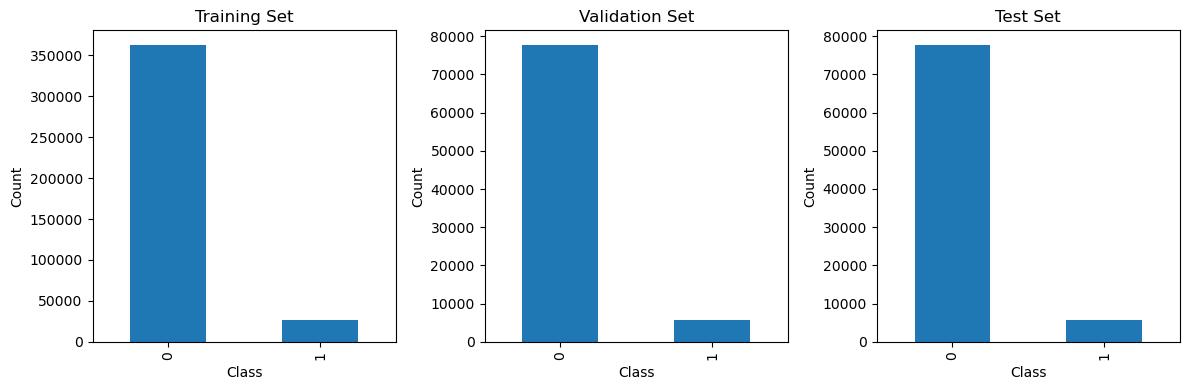


>>> Using positive class for binary metrics: np.int64(1)

=== 2. CONFIGURING MACHINE LEARNING MODELS (OVERFITTING PREVENTION) ===
Configured 2 models with stronger, evidence-based search spaces.
Note: selection & scaling happen inside CV/tuning to stay leakage-safe.


In [1]:
# =====================================================
# COMPLETE MACHINE LEARNING PIPELINE
# Network Intrusion Detection System Implementation
# With Overfitting Prevention Strategies
# =====================================================

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ---- Parallelism policy (set BEFORE importing numpy/sklearn/xgboost) ----
import os
USE_OUTER_PARALLEL = True           # True if using CV/search with n_jobs>1
OUTER_N_JOBS = 8                   # good for your 14-core CPU
INNER_N_JOBS = 1 if USE_OUTER_PARALLEL else -1

if USE_OUTER_PARALLEL:
    # avoid nested threading in low-level math libs
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS only; harmless elsewhere

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from time import time

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, balanced_accuracy_score, make_scorer
)

# Hyperparameter Tuning
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.callbacks import DeltaYStopper

from sklearn.utils.class_weight import compute_sample_weight

# Seed for reproducibility
SEED = 42
np.random.seed(SEED)

# =====================================================
# 1. DATA LOADING AND INITIAL EXPLORATION
# =====================================================
print("\n=== 1. LOADING AND EXPLORING DATASETS ===")

def load_and_explore_data():
    train_df = pd.read_csv('processed_data/train_set.csv')
    val_df   = pd.read_csv('processed_data/validation_set.csv')
    test_df  = pd.read_csv('processed_data/test_set.csv')

    X_train = train_df.drop('Label', axis=1)
    y_train = train_df['Label']
    X_val   = val_df.drop('Label', axis=1)
    y_val   = val_df['Label']
    X_test  = test_df.drop('Label', axis=1)
    y_test  = test_df['Label']

    print("\nClass Distribution Analysis (proportions):")
    print("Training set:\n", y_train.value_counts(normalize=True))
    print("\nValidation set:\n", y_val.value_counts(normalize=True))
    print("\nTest set:\n", y_test.value_counts(normalize=True))

    # Quick bar plots (optional)
    plt.figure(figsize=(12, 4))
    for i, (data, title) in enumerate(
        [(y_train, 'Training Set'), (y_val, 'Validation Set'), (y_test, 'Test Set')], 1
    ):
        plt.subplot(1, 3, i)
        data.value_counts().plot(kind='bar')
        plt.title(title)
        plt.xlabel('Class'); plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_and_explore_data()

# Infer positive class as the minority class in TRAIN (works for binary)
classes, counts = np.unique(y_train, return_counts=True)
pos_class = classes[np.argmin(counts)]
print(f"\n>>> Using positive class for binary metrics: {pos_class!r}")

# =====================================================
# 2. MODEL CONFIGURATION (WITH REGULARIZATION & EARLY STOPPING)
# =====================================================
print("\n=== 2. CONFIGURING MACHINE LEARNING MODELS (OVERFITTING PREVENTION) ===")
"""
class XGBClassifierAuto(XGBClassifier):
    def __init__(self, auto_weight=True, weight_mode="balanced", **kwargs):
        super().__init__(**kwargs); self.auto_weight = auto_weight; self.weight_mode = weight_mode
    def fit(self, X, y, **fit_params):
        if self.auto_weight:
            fit_params = {**fit_params, "sample_weight": compute_sample_weight(self.weight_mode, y)}
        return super().fit(X, y, **fit_params)
        """

# define once (pure Python tuples, not numpy)
_HLS = [(64,), (64, 32), (128,), (128, 64), (256, 128)]
_HLS = [tuple(int(v) for v in h) for h in _HLS]  # sanitize

def get_model_configurations():
    models = {
        "Neural Network": {
            "model": MLPClassifier(
                random_state=SEED, solver="adam", early_stopping=True, 
                validation_fraction=0.15,   # a bit more validation for ES
                n_iter_no_change=15,        # more patience
                max_iter=1000,              # ES will stop earlier if converged
                alpha=1e-3, hidden_layer_sizes=(64, 32),
                learning_rate_init=1e-3, batch_size=1024, 
                activation="relu", shuffle=True
            ),
            "params": {
                # identity ensures tuples go straight through to the estimator
                "hidden_layer_sizes": Categorical(_HLS, transform="identity"),
                "alpha": Real(1e-6, 1e-2, prior="log-uniform"),
                "learning_rate_init": Real(1e-4, 3e-3, prior="log-uniform"),
                "learning_rate": Categorical(["constant", "adaptive"]),
                "activation": Categorical(["relu", "tanh"], transform="identity"),
                # Optional (uncomment if you want to tune it):
                "batch_size": Categorical([256, 512, 1024]),
            }
        },
        
        "Naïve Bayes": {
            "model": GaussianNB(var_smoothing=1e-9),
            "params": {
                "var_smoothing": Real(1e-12, 1e-6, prior="log-uniform")
            }
        }

    }
    print(f"Configured {len(models)} models with stronger, evidence-based search spaces.")
    print("Note: selection & scaling happen inside CV/tuning to stay leakage-safe.")
    return models

model_configs = get_model_configurations()

# Step 2: Training using Cross-Validation and SMOTE

In [2]:
# ==============================================
# 3. 5-FOLD CV: SelectKBest + RobustScaler + SMOTE (LEAKAGE-SAFE, self-contained)
# ==============================================
import os, warnings, logging
warnings.filterwarnings("ignore")

OUTER_N_JOBS = 8
os.environ.pop("LOKY_MAX_CPU_COUNT", None)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

[logging.getLogger(n).setLevel(logging.ERROR) for n in ("joblib", "loky", "sklearn")]

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

print("\n=== 3. 5-FOLD CV: SelectKBest (per-fold) + RobustScaler (per-fold) + SMOTE ===")

try:
    SEED
except NameError:
    SEED = 42

# Selector config declared directly — no saved object, no risk of reusing
# a selector that was fit on already-scaled/already-shrunk data.
K_FEATURES = 60
SCORE_FUNC = f_classif

def perform_cv_with_selector_scaler_smote(model_configs, X_train_full, y_train, k=K_FEATURES, score_func=SCORE_FUNC):
    classes, counts = np.unique(y_train, return_counts=True)
    pos_class = classes[np.argmin(counts)]
    print(f">>> CV positive class assumed as minority: {pos_class!r}")

    total_features = X_train_full.shape[1]
    if k > total_features:
        print(f"⚠️ k={k} exceeds available features ({total_features}); adjusting k to {total_features}.")
        k = total_features
    print(f">>> Using SelectKBest(k={k}, score_func={score_func.__name__}) inside each fold.")
    print(">>> RobustScaler is fit fresh per fold inside the pipeline — never loaded or fit globally.")

    scoring = {
        'accuracy':  'accuracy',
        'precision': make_scorer(precision_score, pos_label=pos_class),
        'recall':    make_scorer(recall_score,    pos_label=pos_class),
        'f1':        make_scorer(f1_score,        pos_label=pos_class),
        'roc_auc':   'roc_auc'
    }

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_results = {}

    for name, config in model_configs.items():
        print(f"\nEvaluating {name} with per-fold selection + scaling + SMOTE...")

        pipe = Pipeline(steps=[
            ('select', SelectKBest(score_func=score_func, k=k)),
            ('scaler', RobustScaler(quantile_range=(25.0, 75.0))),
            ('smote',  SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=SEED)),
            ('clf',    config['model'])
        ])

        try:
            scores = cross_validate(
                estimator=pipe,
                X=X_train_full,
                y=y_train,
                cv=kfold,
                scoring=scoring,
                n_jobs=OUTER_N_JOBS,
                pre_dispatch=OUTER_N_JOBS,
                return_train_score=False,
                error_score='raise'
            )

            cv_metrics = {
                metric: {
                    'mean': float(np.mean(scores[f'test_{metric}'])),
                    'std':  float(np.std(scores[f'test_{metric}']))
                }
                for metric in scoring.keys()
            }
            cv_results[name] = cv_metrics

            print(f"F1: {cv_metrics['f1']['mean']:.4f} (±{cv_metrics['f1']['std']:.4f}) | "
                  f"AUC: {cv_metrics['roc_auc']['mean']:.4f}")

        except Exception as e:
            print(f"Cross-validation failed for {name}: {e}")

    return cv_results

# X_train here = the cleaned, FULL-feature, unscaled set from Step 9/10 above
# (or train_set.csv minus the target column, if loading from disk)
cv_results = perform_cv_with_selector_scaler_smote(model_configs, X_train, y_train)


=== 3. 5-FOLD CV: SelectKBest (per-fold) + RobustScaler (per-fold) + SMOTE ===
>>> CV positive class assumed as minority: np.int64(1)
⚠️ k=60 exceeds available features (57); adjusting k to 57.
>>> Using SelectKBest(k=57, score_func=f_classif) inside each fold.
>>> RobustScaler is fit fresh per fold inside the pipeline — never loaded or fit globally.

Evaluating Neural Network with per-fold selection + scaling + SMOTE...
F1: 0.4432 (±0.0023) | AUC: 0.8739

Evaluating Naïve Bayes with per-fold selection + scaling + SMOTE...
F1: 0.1330 (±0.0003) | AUC: 0.6562


# Step 3: Hyperparameter Tuning and Validation


=== 4. TUNING MODELS WITH BAYESIAN OPTIMIZATION (selection+scaling+SMOTE in-pipeline) ===
>>> Optimization pos_label: np.int64(1)
⚠️ k=60 exceeds available features (57); adjusting k to 57.
>>> Using SelectKBest(k=57, score_func=f_classif) in each CV split.

Optimizing Neural Network...
Failed to optimize Neural Network: can only convert an array of size 1 to a Python scalar
Using default parameters inside the same leakage-safe pipeline...
⏱️ Neural Network fallback fit time (SMOTE): 61.34s

Optimizing Naïve Bayes...
Best CV F1(np.int64(1)): 0.1343
Best parameters: OrderedDict([('clf__var_smoothing', 7.848696955037492e-11)])
⏱️ Naïve Bayes optimization time (SMOTE, n_iter=8): 29.41s

=== Training time summary (SMOTE) ===
Naïve Bayes                29.41s
Neural Network             61.34s (fallback)
TOTAL                      90.75s

=== 5. VALIDATING OPTIMIZED MODELS ===

Evaluating Neural Network on validation set...

Performance Comparison:
CV F1(np.int64(1)): nan
VAL F1(np.int64(1)

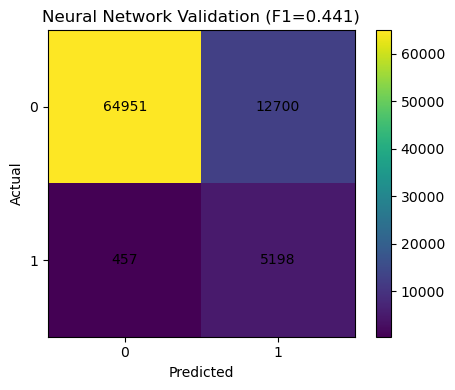


Evaluating Naïve Bayes on validation set...

Performance Comparison:
CV F1(np.int64(1)): 0.1343
VAL F1(np.int64(1)): 0.1352
⏱️ Train time: 29.41s
              precision    recall  f1-score   support

           0       0.99      0.08      0.14     77651
           1       0.07      0.99      0.14      5655

    accuracy                           0.14     83306
   macro avg       0.53      0.53      0.14     83306
weighted avg       0.93      0.14      0.14     83306



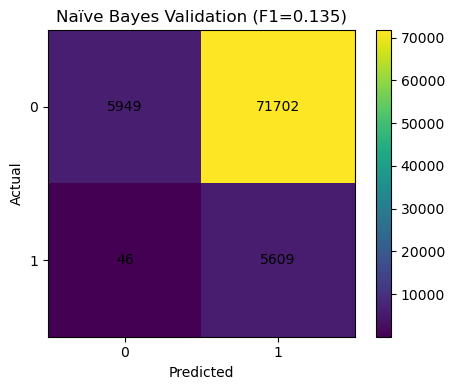

✅ Saved optimized models dict to: processed_data\objects\optimized_models.pkl
✅ Saved bayes results to: processed_data\objects\bayes_results.pkl
📄 Metadata: processed_data\objects\metadata.json
👌 No best model was chosen or saved.
CWD: C:\Users\SUNDARPC\Documents\Machine Learning\Final Model
Saved to: C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects
 - C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects\bayes_results.pkl
 - C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects\metadata.json
 - C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects\Na_ve_Bayes.joblib
 - C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects\Neural_Network.joblib
 - C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects\optimized_models.pkl
 - C:\Users\SUNDARPC\Documents\Machine Learning\Final Model\processed_data\objects\RFXGBDT


In [3]:
# =======================================================
# 4. BAYESIAN HYPERPARAMETER OPTIMIZATION (LEAKAGE-SAFE)
# SelectKBest + RobustScaler + SMOTE inside the pipeline
# ======================================================

import os
OUTER_N_JOBS = 8
os.environ.pop("LOKY_MAX_CPU_COUNT", None)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

import time
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.callbacks import DeltaYStopper
import numpy as np
import matplotlib.pyplot as plt

import re, json
from pathlib import Path
from datetime import datetime
import joblib

print("\n=== 4. TUNING MODELS WITH BAYESIAN OPTIMIZATION (selection+scaling+SMOTE in-pipeline) ===")

# Same selection config as the CV comparison script — declared once, not
# pulled from a saved selector object, so the two stages can't drift apart.
K_FEATURES = 60
SCORE_FUNC = f_classif

def _fmt_secs(s):
    return f"{s:.2f}s" if s < 120 else f"{s/60:.2f}min"

def optimize_models(model_configs, X_train_full_unscaled, y_train, k=K_FEATURES, score_func=SCORE_FUNC, seed=SEED):
    classes, counts = np.unique(y_train, return_counts=True)
    pos_class = classes[np.argmin(counts)]
    print(f">>> Optimization pos_label: {pos_class!r}")

    total_features = X_train_full_unscaled.shape[1]
    if k > total_features:
        print(f"⚠️ k={k} exceeds available features ({total_features}); adjusting k to {total_features}.")
        k = total_features
    print(f">>> Using SelectKBest(k={k}, score_func={score_func.__name__}) in each CV split.")

    f1_pos = make_scorer(f1_score, pos_label=pos_class)

    optimized_models = {}
    bayes_results = {}

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

    per_model_iters = {
        "XGBoost":         20,
        "Random Forest":   16,
        "Extra Trees":     16,
        "Decision Tree":   14,
        "KNN":             16,
        "Linear SVM":      16,
        "Logistic Regression": 16,
        "Neural Network":  12,
        "Naïve Bayes":     8,
    }

    resampler_name = "SMOTE"  # change this string when you switch resamplers, used for logging/metadata only

    for name, config in model_configs.items():
        print(f"\nOptimizing {name}...")

        pipe = Pipeline(steps=[
            ('select', SelectKBest(score_func=score_func, k=k)),
            ('scaler', RobustScaler(quantile_range=(25.0, 75.0))),
            ('smote',  SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=seed)),
            ('clf',    clone(config['model']))  # keep n_jobs=1 inside models
        ])

        param_grid = {f'clf__{k_}': v for k_, v in config['params'].items()}
        n_iter = per_model_iters.get(name, 24)
        n_points = min(OUTER_N_JOBS, 10)

        t_start = time.perf_counter()
        try:
            opt = BayesSearchCV(
                estimator=pipe,
                search_spaces=param_grid,
                n_iter=n_iter,
                cv=inner_cv,
                n_jobs=OUTER_N_JOBS,
                n_points=n_points,
                pre_dispatch=OUTER_N_JOBS,
                random_state=seed,
                scoring=f1_pos,
                refit=True,
                return_train_score=False,
                error_score=np.nan,
                optimizer_kwargs={"base_estimator": "RF"}
            )
            try:
                stopper = DeltaYStopper(delta=1e-4, n_best=3)
            except TypeError:
                stopper = DeltaYStopper(delta=1e-4)

            opt.fit(X_train_full_unscaled, y_train, callback=stopper)
            train_time = time.perf_counter() - t_start

            optimized_models[name] = opt.best_estimator_
            bayes_results[name] = {
                'best_params': opt.best_params_,
                'best_cv_score': float(opt.best_score_),
                'validation_score': None,
                'pos_label': pos_class,
                'resampler': resampler_name,
                'train_time_sec': float(train_time),
                'n_iter': n_iter,
                'fallback_used': False
            }
            print(f"Best CV F1({pos_class!r}): {opt.best_score_:.4f}")
            print(f"Best parameters: {opt.best_params_}")
            print(f"⏱️ {name} optimization time ({resampler_name}, n_iter={n_iter}): {_fmt_secs(train_time)}")

        except Exception as e:
            print(f"Failed to optimize {name}: {e}")
            print("Using default parameters inside the same leakage-safe pipeline...")

            fallback_pipe = Pipeline(steps=[
                ('select', SelectKBest(score_func=score_func, k=k)),
                ('scaler', RobustScaler(quantile_range=(25.0, 75.0))),
                ('smote',  SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=seed)),
                ('clf',    clone(config['model']))
            ])
            t_fallback_start = time.perf_counter()
            fallback_pipe.fit(X_train_full_unscaled, y_train)
            train_time = time.perf_counter() - t_fallback_start

            optimized_models[name] = fallback_pipe
            bayes_results[name] = {
                'best_params': "default",
                'best_cv_score': np.nan,
                'validation_score': None,
                'pos_label': pos_class,
                'resampler': resampler_name,
                'train_time_sec': float(train_time),
                'n_iter': 0,
                'fallback_used': True
            }
            print(f"⏱️ {name} fallback fit time ({resampler_name}): {_fmt_secs(train_time)}")

    # Summary table for quick cross-resampler comparison later
    print(f"\n=== Training time summary ({resampler_name}) ===")
    for name, res in sorted(bayes_results.items(), key=lambda kv: kv[1]['train_time_sec']):
        tag = " (fallback)" if res['fallback_used'] else ""
        print(f"{name:22s} {_fmt_secs(res['train_time_sec']):>10s}{tag}")
    total_time = sum(r['train_time_sec'] for r in bayes_results.values())
    print(f"{'TOTAL':22s} {_fmt_secs(total_time):>10s}")

    return optimized_models, bayes_results

# X_train here = the cleaned, FULL-feature, unscaled set from Step 9/10
optimized_models, bayes_results = optimize_models(model_configs, X_train, y_train)

# =========================
# Persist optimized models
# =========================
def _slug(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9._-]+', '_', name).strip('_')

def persist_optimized_artifacts(
    optimized_models: dict,
    bayes_results: dict = None,
    out_dir: str = "processed_data/objects",
    compress_level: int = 3
):
    """
    Saves (without selecting a 'best' model):
      - processed_data/objects/optimized_models.pkl  (dict of fitted estimators/pipelines)
      - processed_data/objects/bayes_results.pkl     (if provided; includes per-model train_time_sec)
      - processed_data/objects/<ModelName>.joblib   (one file per model)
      - processed_data/objects/metadata.json        (summary; no best model field; includes timing)
    """
    if not optimized_models or not isinstance(optimized_models, dict):
        raise ValueError("optimized_models must be a non-empty dict of fitted estimators/pipelines.")

    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    models_pkl = out / "optimized_models.pkl"
    joblib.dump(optimized_models, models_pkl, compress=compress_level)

    if bayes_results is not None:
        joblib.dump(bayes_results, out / "bayes_results.pkl", compress=compress_level)

    per_model_paths = {}
    for name, model in optimized_models.items():
        p = out / f"{_slug(name)}.joblib"
        joblib.dump(model, p, compress=compress_level)
        per_model_paths[name] = str(p)

    timing_summary = {}
    if bayes_results is not None:
        timing_summary = {
            name: {
                "train_time_sec": res.get("train_time_sec"),
                "resampler": res.get("resampler"),
                "fallback_used": res.get("fallback_used", False)
            }
            for name, res in bayes_results.items()
        }
        total_train_time_sec = sum(
            res.get("train_time_sec", 0.0) for res in bayes_results.values()
        )
    else:
        total_train_time_sec = None

    meta = {
        "saved_at": datetime.utcnow().isoformat() + "Z",
        "n_models": len(optimized_models),
        "models": list(optimized_models.keys()),
        "per_model_paths": per_model_paths,
        "bayes_results_saved": bool(bayes_results is not None),
        "timing_summary": timing_summary,
        "total_train_time_sec": total_train_time_sec,
        "note": "No best model selected at this stage.",
    }
    (out / "metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

    print(f"✅ Saved optimized models dict to: {models_pkl}")
    if bayes_results is not None:
        print(f"✅ Saved bayes results to: {out/'bayes_results.pkl'}")
    print(f"📄 Metadata: {out/'metadata.json'}")
    print("👌 No best model was chosen or saved.")

# ==============================================
# 5. VALIDATION EVALUATION (consumes unscaled X_val; pipeline handles transforms)
# ==============================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("\n=== 5. VALIDATING OPTIMIZED MODELS ===")

def _predict_proba_or_decision(estimator, X):
    clf = estimator.named_steps['clf']
    if hasattr(clf, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(clf, "decision_function"):
        return estimator.decision_function(X)
    return None

def evaluate_on_validation(optimized_models, bayes_results, X_val_full_unscaled, y_val):
    pos_class = next(iter(bayes_results.values()))['pos_label'] if bayes_results else 1
    val_metrics = {}

    for name, model in optimized_models.items():
        print(f"\nEvaluating {name} on validation set...")

        try:
            y_pred = model.predict(X_val_full_unscaled)

            acc = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, pos_label=pos_class, zero_division=0)
            rec  = recall_score(y_val, y_pred, pos_label=pos_class, zero_division=0)
            f1   = f1_score(y_val, y_pred, pos_label=pos_class, zero_division=0)

            scores = _predict_proba_or_decision(model, X_val_full_unscaled)
            auc = roc_auc_score(y_val, scores) if scores is not None else np.nan

            best_cv = bayes_results[name]['best_cv_score']
            train_time = bayes_results[name].get('train_time_sec')
            bayes_results[name]['validation_score'] = float(f1)

            val_metrics[name] = {
                'Accuracy': float(acc),
                f'Precision ({pos_class})': float(prec),
                f'Recall ({pos_class})': float(rec),
                f'F1 ({pos_class})': float(f1),
                'ROC AUC': float(auc) if not np.isnan(auc) else "N/A",
                'CV_F1': float(best_cv) if best_cv == best_cv else "N/A",
                'Train_Time_Sec': float(train_time) if train_time is not None else "N/A"
            }

            print("\nPerformance Comparison:")
            print(f"CV F1({pos_class!r}): {best_cv if isinstance(best_cv, str) else f'{best_cv:.4f}'}")
            print(f"VAL F1({pos_class!r}): {f1:.4f}")
            if train_time is not None:
                print(f"⏱️ Train time: {_fmt_secs(train_time)}")
            print(classification_report(y_val, y_pred, labels=[c for c in np.unique(y_val)],
                  zero_division=0))

            cm = confusion_matrix(y_val, y_pred, labels=np.unique(y_val))
            fig, ax = plt.subplots(figsize=(5, 4))
            im = ax.imshow(cm, interpolation='nearest')
            ax.set_title(f'{name} Validation (F1={f1:.3f})')
            ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
            ax.set_xticks(range(len(np.unique(y_val)))); ax.set_yticks(range(len(np.unique(y_val))))
            ax.set_xticklabels([str(c) for c in np.unique(y_val)])
            ax.set_yticklabels([str(c) for c in np.unique(y_val)])
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, cm[i, j], ha="center", va="center")
            fig.colorbar(im, ax=ax)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Failed to evaluate {name}: {e}")
            val_metrics[name] = {'Error': str(e)}

    return val_metrics, bayes_results

# Pass the FULL, UN-SCALED validation matrix; the pipeline handles transforms.
val_metrics, bayes_results = evaluate_on_validation(optimized_models, bayes_results, X_val, y_val)

persist_optimized_artifacts(
    optimized_models=optimized_models,
    bayes_results=bayes_results,
    out_dir="processed_data/objects",
    compress_level=3
)

print("CWD:", Path.cwd().resolve())
print("Saved to:", Path("processed_data/objects").resolve())
for p in sorted(Path("processed_data/objects").resolve().iterdir()):
    print(" -", p)

# Step 4: Final Testing


=== FINAL TESTING EVALUATION ===
Loading optimized models from processed_data/objects/optimized_models.pkl
Loading bayes_results from processed_data/objects/bayes_results.pkl
>>> Test-time positive class: np.int64(1)

🧪 Testing Neural Network on test set...

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     77638
           1       0.30      0.92      0.45      5654

    accuracy                           0.85     83292
   macro avg       0.64      0.88      0.68     83292
weighted avg       0.95      0.85      0.88     83292



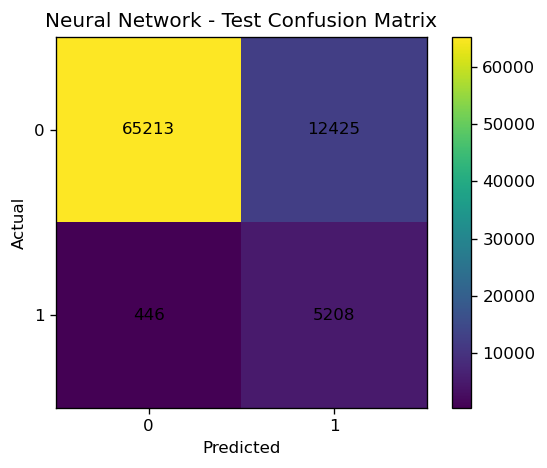

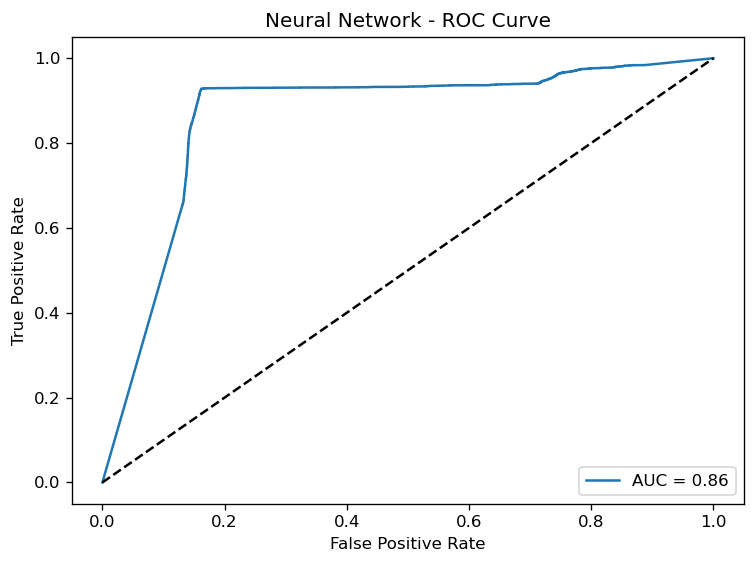


🧪 Testing Naïve Bayes on test set...

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.08      0.14     77638
           1       0.07      0.99      0.14      5654

    accuracy                           0.14     83292
   macro avg       0.53      0.53      0.14     83292
weighted avg       0.93      0.14      0.14     83292



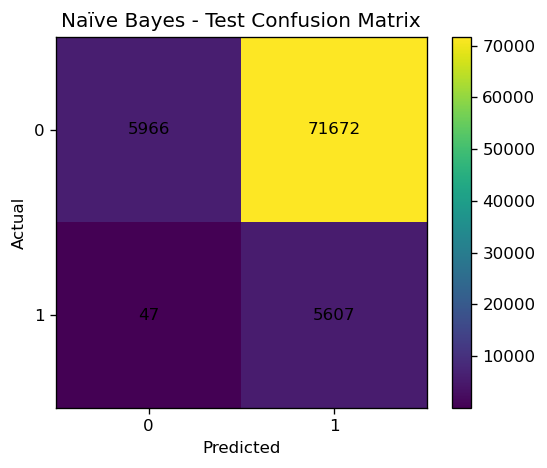

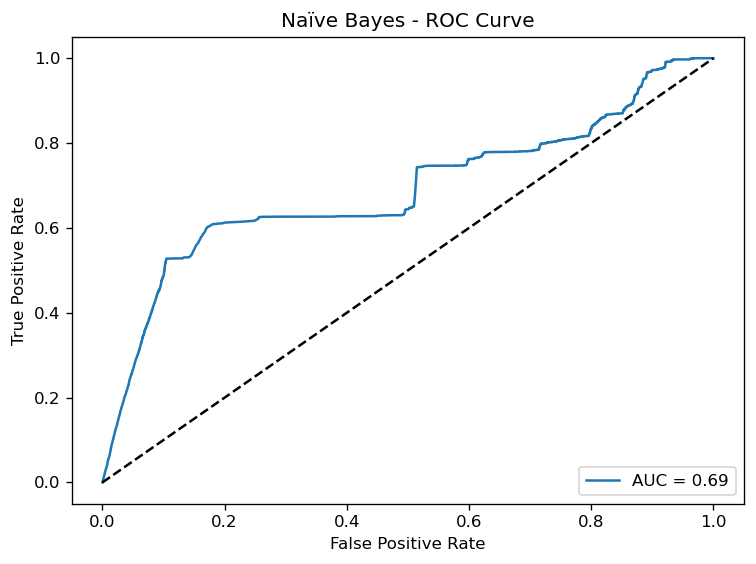


✅ Saved test metrics to: processed_data/outputs\test_metrics.csv

=== Test Metrics Summary ===
            Model  Accuracy  Precision (1)  Recall (1)    F1 (1)   ROC AUC
0  Neural Network  0.845471       0.295355    0.921118  0.447288  0.863649
1     Naïve Bayes  0.138945       0.072555    0.991687  0.135218  0.689447


In [4]:
# ===================
# 5. Final Testing
# ==================
# final_testing_evaluation.py
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import joblib

plt.rcParams["figure.dpi"] = 120

print("\n=== FINAL TESTING EVALUATION ===")

# --------------------------------------------------
# Helper utilities
# --------------------------------------------------
def _infer_pos_label(bayes_results, y_test):
    """Use the pos_label chosen during tuning; fallback to minority in y_test."""
    if bayes_results and len(bayes_results) > 0:
        first = next(iter(bayes_results.values()))
        if isinstance(first, dict) and "pos_label" in first:
            return first["pos_label"]
    classes, counts = np.unique(y_test, return_counts=True)
    return classes[np.argmin(counts)]

def _scores_for_auc(estimator, X):
    """Return score vector for ROC AUC (proba or decision_function); else None."""
    clf = estimator
    if hasattr(estimator, "named_steps"):
        clf = estimator.named_steps.get("clf", estimator)
    # Use the full pipeline to transform + predict scores
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    # If only the final clf exposes these, try via clf (rare case)
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, "decision_function"):
        return clf.decision_function(X)
    return None

def _plot_confusion_matrix(cm, labels, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels([str(c) for c in labels])
    ax.set_yticklabels([str(c) for c in labels])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

def _plot_roc_curve(y_true, scores, auc, title, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend(loc="lower right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# --------------------------------------------------
# Evaluate Models on Final Test Set
# --------------------------------------------------
def evaluate_on_test(optimized_models, X_test_full_unscaled, y_test, bayes_results=None,
                     out_dir="processed_data/outputs"):
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    # Positive label
    pos_label = _infer_pos_label(bayes_results, y_test)
    print(f">>> Test-time positive class: {pos_label!r}")

    # Stable label order for reports/plots
    label_order = sorted(np.unique(y_test), key=lambda x: str(x))

    all_rows = []
    for name, model in optimized_models.items():
        print(f"\n🧪 Testing {name} on test set...")

        try:
            # Predict using the full pipeline on UN-SCALED features
            y_pred = model.predict(X_test_full_unscaled)
        except Exception as e:
            print(f"❌ Prediction failed for {name}: {e}")
            all_rows.append({
                "Model": name, "Accuracy": "N/A",
                f"Precision ({pos_label})": "N/A",
                f"Recall ({pos_label})": "N/A",
                f"F1 ({pos_label})": "N/A",
                "ROC AUC": "N/A", "Error": str(e)
            })
            continue

        # Scores for AUC
        try:
            scores = _scores_for_auc(model, X_test_full_unscaled)
            roc_auc = roc_auc_score(y_test, scores) if scores is not None else np.nan
        except Exception:
            scores, roc_auc = None, np.nan

        # Metrics (benign/malicious naming depends on your label values; we report for pos_label)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        rec  = recall_score(y_test, y_pred,   pos_label=pos_label, zero_division=0)
        f1   = f1_score(y_test, y_pred,       pos_label=pos_label, zero_division=0)

        # Classification report
        print("\n📊 Classification Report:")
        print(classification_report(y_test, y_pred, labels=label_order, zero_division=0))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, labels=label_order)
        _plot_confusion_matrix(
            cm, label_order, title=f"{name} - Test Confusion Matrix",
            save_path=os.path.join(out_dir, f"{name}_confusion_matrix.png")
        )

        # ROC Curve if available
        if scores is not None and isinstance(roc_auc, (int, float, np.floating)) and not np.isnan(roc_auc):
            _plot_roc_curve(
                y_test, scores, roc_auc,
                title=f"{name} - ROC Curve",
                save_path=os.path.join(out_dir, f"{name}_roc_curve.png")
            )

        all_rows.append({
            "Model": name,
            "Accuracy": float(acc),
            f"Precision ({pos_label})": float(prec),
            f"Recall ({pos_label})": float(rec),
            f"F1 ({pos_label})": float(f1),
            "ROC AUC": float(roc_auc) if isinstance(roc_auc, (int, float, np.floating)) and not np.isnan(roc_auc) else "N/A"
        })

    # To DataFrame + CSV
    df = pd.DataFrame(all_rows)
    csv_path = os.path.join(out_dir, "test_metrics.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n✅ Saved test metrics to: {csv_path}")
    return df

# --------------------------------------------------
# Script entry-point (works either in a script or notebook)
# --------------------------------------------------
if __name__ == "__main__":
    # 1) Load test set (UN-SCALED). Assumes ' Label' is the target column (space before Label).
    test_csv = "processed_data/test_set.csv"
    if not Path(test_csv).exists():
        raise FileNotFoundError(f"Could not find {test_csv}. Make sure the path is correct.")

    test_df = pd.read_csv(test_csv)
    if "Label" not in test_df.columns:
        raise KeyError("Target column 'Label' not found in test_set.csv")

    X_test = test_df.drop("Label", axis=1)
    y_test = test_df["Label"]

    # 2) Load optimized models and bayes_results if saved; otherwise assume available in memory.
    #    Adjust these paths to where you saved them (if you did).
    models_pkl = "processed_data/objects/optimized_models.pkl"
    bayes_pkl  = "processed_data/objects/bayes_results.pkl"

    if Path(models_pkl).exists():
        print(f"Loading optimized models from {models_pkl}")
        optimized_models = joblib.load(models_pkl)
    else:
        try:
            optimized_models  # type: ignore
        except NameError:
            raise RuntimeError(
                "optimized_models not found in memory and no pickle at "
                f"{models_pkl}. Load/fit models before running final testing."
            )

    bayes_results = None
    if Path(bayes_pkl).exists():
        print(f"Loading bayes_results from {bayes_pkl}")
        bayes_results = joblib.load(bayes_pkl)
    else:
        try:
            bayes_results  # type: ignore
        except NameError:
            print("⚠️ bayes_results not found; will infer pos_label from y_test.")

    # 3) Evaluate
    metrics_df = evaluate_on_test(optimized_models, X_test, y_test, bayes_results=bayes_results,
                                  out_dir="processed_data/outputs")

    # 4) Print a quick summary table
    pd.set_option("display.max_colwidth", 100)
    print("\n=== Test Metrics Summary ===")
    print(metrics_df)

# Step 5a: SHAP ExplainabilityStep 5a: SHAP Explainability

In [5]:
# ===============================
# 5a. SHAP Explainability (global)
# ===============================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from shap import maskers
from sklearn.pipeline import Pipeline

def _inner_estimator(est):
    """Return the final classifier even if wrapped in a Pipeline."""
    if hasattr(est, "named_steps"):
        return est.named_steps.get("clf", list(est.named_steps.values())[-1])
    return est

def _transform_up_to_clf(pipeline, X_df: pd.DataFrame):
    """
    Pass X through all pipeline steps *before* the final classifier.
    - Skips imblearn samplers (e.g., SMOTE) at test-time.
    - Uses get_support() / get_feature_names_out() to keep real feature names.
    """
    # If it's not a pipeline, just return raw values + original names
    if not hasattr(pipeline, "steps") and not hasattr(pipeline, "named_steps"):
        return X_df.values, list(X_df.columns)

    names = list(X_df.columns)
    X_work = X_df

    def _is_sampler(step):
        # Samplers typically have fit_resample but no transform
        return hasattr(step, "fit_resample") and not hasattr(step, "transform")

    for step_name, step in list(getattr(pipeline, "named_steps", {}).items()):
        if step_name == "clf":
            break

        if _is_sampler(step):
            continue

        if not hasattr(step, "transform"):
            continue

        # ---- apply transform ----
        X_work = step.transform(X_work)

        # ---- feature selectors (SelectKBest, VarianceThreshold, etc.) ----
        if hasattr(step, "get_support"):
            mask = step.get_support()
            if hasattr(mask, "__len__") and len(mask) == len(names):
                idx = np.arange(len(names))[mask]
                names = [names[i] for i in idx]

        # ---- transformers that can give explicit output names ----
        elif hasattr(step, "get_feature_names_out"):
            try:
                # most sklearn transformers support this
                names = list(step.get_feature_names_out(names))
            except TypeError:
                # some ignore the input_features arg
                names = list(step.get_feature_names_out())

        # ---- generic numpy output (no name info) ----
        if isinstance(X_work, np.ndarray):
            if X_work.ndim == 1:
                X_work = X_work.reshape(-1, 1)

            # If we *still* have a mismatch and no better info, last resort
            if X_work.shape[1] != len(names):
                names = [f"feat_{i}" for i in range(X_work.shape[1])]

    X_arr = X_work.values if hasattr(X_work, "values") else np.asarray(X_work)
    return X_arr, names


def _pick_shap_explainer(inner_clf, background_arr):
    """
    Chooses a robust SHAP explainer and ensures a callable masker for
    linear and model-agnostic paths.

    Returns: (explainer, uses_function)
    """
    name = type(inner_clf).__name__.lower()

    def _agnostic():
        m = maskers.Independent(background_arr)  # callable masker
        if hasattr(inner_clf, "predict_proba"):
            f = inner_clf.predict_proba
        elif hasattr(inner_clf, "decision_function"):
            f = inner_clf.decision_function
        else:
            f = inner_clf.predict
        return shap.Explainer(f, m), True

    try:
        # Tree models → TreeExplainer
        if any(k in name for k in [
            "xgb", "lgbm", "randomforest", "extratrees",
            "gradientboost", "decisiontree", "catboost"
        ]):
            return shap.TreeExplainer(inner_clf), False

        # Linear models → LinearExplainer + Independent masker
        is_linear = (
            "logisticregression" in name or
            "logisticregressioncv" in name or
            "linearsvc" in name or
            (name == "svc" and getattr(inner_clf, "kernel", None) == "linear") or
            ("sgdclassifier" in name and getattr(inner_clf, "loss", None) in ("log", "log_loss"))
        )
        if is_linear:
            m = maskers.Independent(background_arr)
            return shap.LinearExplainer(inner_clf, m), False

        # Everything else (KNN, MLP, NB, non-linear SVM, etc.) → model-agnostic
        return _agnostic()

    except Exception:
        # Fallback to model-agnostic
        return _agnostic()

def _summarize_shap_values(shap_values, feature_names):
    """
    Return mean(|SHAP|) per feature.

    Works for:
    - (n_samples, n_features)
    - (n_samples, n_features, n_outputs)  e.g. 2-class probabilities
    - (n_outputs, n_samples, n_features)
    - lists/arrays from older SHAP versions

    It tries to detect which axis is the *feature* axis by
    matching its length to len(feature_names).
    """
    # Get raw values
    try:
        vals = shap_values.values   # SHAP Explanation
    except Exception:
        vals = shap_values          # numpy array or list

    vals = np.asarray(vals)

    # Degenerate case
    if vals.ndim == 1:
        return np.array([np.mean(np.abs(vals))])

    n_expected_features = len(feature_names)

    # 1) Try to locate feature axis by matching length
    feat_axis = None
    for ax, dim in enumerate(vals.shape):
        if dim == n_expected_features:
            feat_axis = ax
            break

    # 2) Fallback if no axis matches (rare) → assume last axis
    if feat_axis is None:
        feat_axis = vals.ndim - 1

    # 3) Average absolute SHAP over all non-feature axes
    other_axes = tuple(ax for ax in range(vals.ndim) if ax != feat_axis)
    return np.mean(np.abs(vals), axis=other_axes)

def _plot_shap_bar(importances, feature_names, title, save_path):
    order = np.argsort(importances)[::-1]
    top = order[:20]
    plt.figure(figsize=(7, 5))
    plt.barh([feature_names[i] for i in top][::-1], importances[top][::-1])
    plt.title(title)
    plt.xlabel("Mean |SHAP| (global importance)")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.close()

def run_shap_for_models(optimized_models: dict, X_test_full_unscaled: pd.DataFrame,
                        out_dir="processed_data/outputs", sample_n=2000, verbose=False):
    """
    Computes global SHAP importances on the test set (or a subsample) and saves:
      - <Model>_shap_importances.csv  (full ranked importances)
      - <Model>_shap_bar.png          (Top-20 bar)
      - <Model>_shap_summary.png      (beeswarm; best effort)
    """
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    # Subsample to keep runtime/memory stable for model-agnostic explainers
    if len(X_test_full_unscaled) > sample_n:
        idx = np.random.RandomState(42).choice(len(X_test_full_unscaled), sample_n, replace=False)
        X_small = X_test_full_unscaled.iloc[idx].copy()
    else:
        X_small = X_test_full_unscaled.copy()

    for name, model in optimized_models.items():
        print(f"\n🔎 Computing SHAP for {name}...")

        # --- Skip KNN (or any model that is too slow) ---
        if "knn" in name.lower():
            print("   ⏩ Skipping SHAP for KNN to save time.")
            continue

        # 1) Transform up to clf so SHAP sees what the model sees
        if isinstance(model, Pipeline):
            X_for_shap, feat_names = _transform_up_to_clf(model, X_small)
            inner = _inner_estimator(model)
        else:
            X_for_shap, feat_names = X_small.values, list(X_small.columns)
            inner = _inner_estimator(model)

        # 2) Build a background (array) for linear / agnostic explainers
        def _as_array(x):
            if hasattr(x, "data"):
                try:
                    return np.asarray(x.data)
                except Exception:
                    pass
            if hasattr(x, "values"):
                try:
                    return np.asarray(x.values)
                except Exception:
                    pass
            return np.asarray(x)

        try:
            background = shap.kmeans(X_for_shap, 50)
        except Exception:
            bsz = min(200, len(X_for_shap))
            rng = np.random.RandomState(42)
            background = X_for_shap[rng.choice(len(X_for_shap), bsz, replace=False)]
        background_arr = _as_array(background)

        # 3) Explainer + SHAP values
        explainer, uses_function = _pick_shap_explainer(inner, background_arr)
        if verbose:
            chosen = type(explainer).__name__
            print(f"   Using {chosen} (function_wrapped={uses_function})")
        shap_values = explainer(X_for_shap)

        # 4) Global importances
        # 4) Global importances
        mean_abs = _summarize_shap_values(shap_values, feat_names)
        if len(mean_abs) != len(feat_names):
            raise ValueError(
                f"SHAP returned {len(mean_abs)} features but feat_names has "
                f"{len(feat_names)}. There is a mismatch in your pipeline "
        f"feature mapping."
        )

        imp_df = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs}) \
                   .sort_values("mean_abs_shap", ascending=False)
        csv_path = os.path.join(out_dir, f"{name}_shap_importances.csv")
        imp_df.to_csv(csv_path, index=False)
        print(f"   ✅ Saved: {csv_path}")

        bar_path = os.path.join(out_dir, f"{name}_shap_bar.png")
        _plot_shap_bar(imp_df["mean_abs_shap"].values, imp_df["feature"].values,
                       title=f"{name} – Global Feature Importance (SHAP)",
                       save_path=bar_path)
        print(f"   ✅ Saved: {bar_path}")

        # 5) Beeswarm (best effort)
        try:
            plt.figure()
            shap.summary_plot(shap_values, X_for_shap, feature_names=feat_names, show=False)
            beeswarm_path = os.path.join(out_dir, f"{name}_shap_summary.png")
            plt.tight_layout()
            plt.savefig(beeswarm_path, bbox_inches="tight")
            plt.close()
            print(f"   ✅ Saved: {beeswarm_path}")
        except Exception as e:
            print(f"   ⚠️ Could not render beeswarm for {name}: {e}")

def report_top_shap(optimized_models, out_dir="processed_data/outputs", k=10):
    """Print Top-k SHAP features per model from the CSVs you just saved."""
    for name in optimized_models.keys():
        path = os.path.join(out_dir, f"{name}_shap_importances.csv")
        if not os.path.exists(path):
            print(f"\n⚠️ No SHAP CSV for {name} at {path}")
            continue
        df = pd.read_csv(path).head(k)
        print(f"\n🔝 Top {k} features for {name}:")
        for i, (feat, val) in enumerate(zip(df["feature"], df["mean_abs_shap"]), start=1):
            print(f"  {i}. {feat}  (mean|SHAP|={val:.6f})")

# Step 5: Results Analysis


=== 5) RESULTS ANALYSIS ===

📊 Performance Comparison Across All Phases:



,CV_Accuracy,CV_F1,CV_ROC AUC,Val_Accuracy,Val_F1,Val_Precision,Val_Recall,Val_ROC AUC,Test_Accuracy,Test_F1,Test_Precision,Test_Recall,Test_ROC AUC
Naïve Bayes,0.134908,0.132976,0.656154,0.138742,0.135212,0.072551,0.991866,0.683715,0.138945,0.135218,0.072555,0.991687,0.689447
Neural Network,0.840427,0.443156,0.873912,0.842064,0.441388,0.290424,0.919187,0.862331,0.845471,0.447288,0.295355,0.921118,0.863649


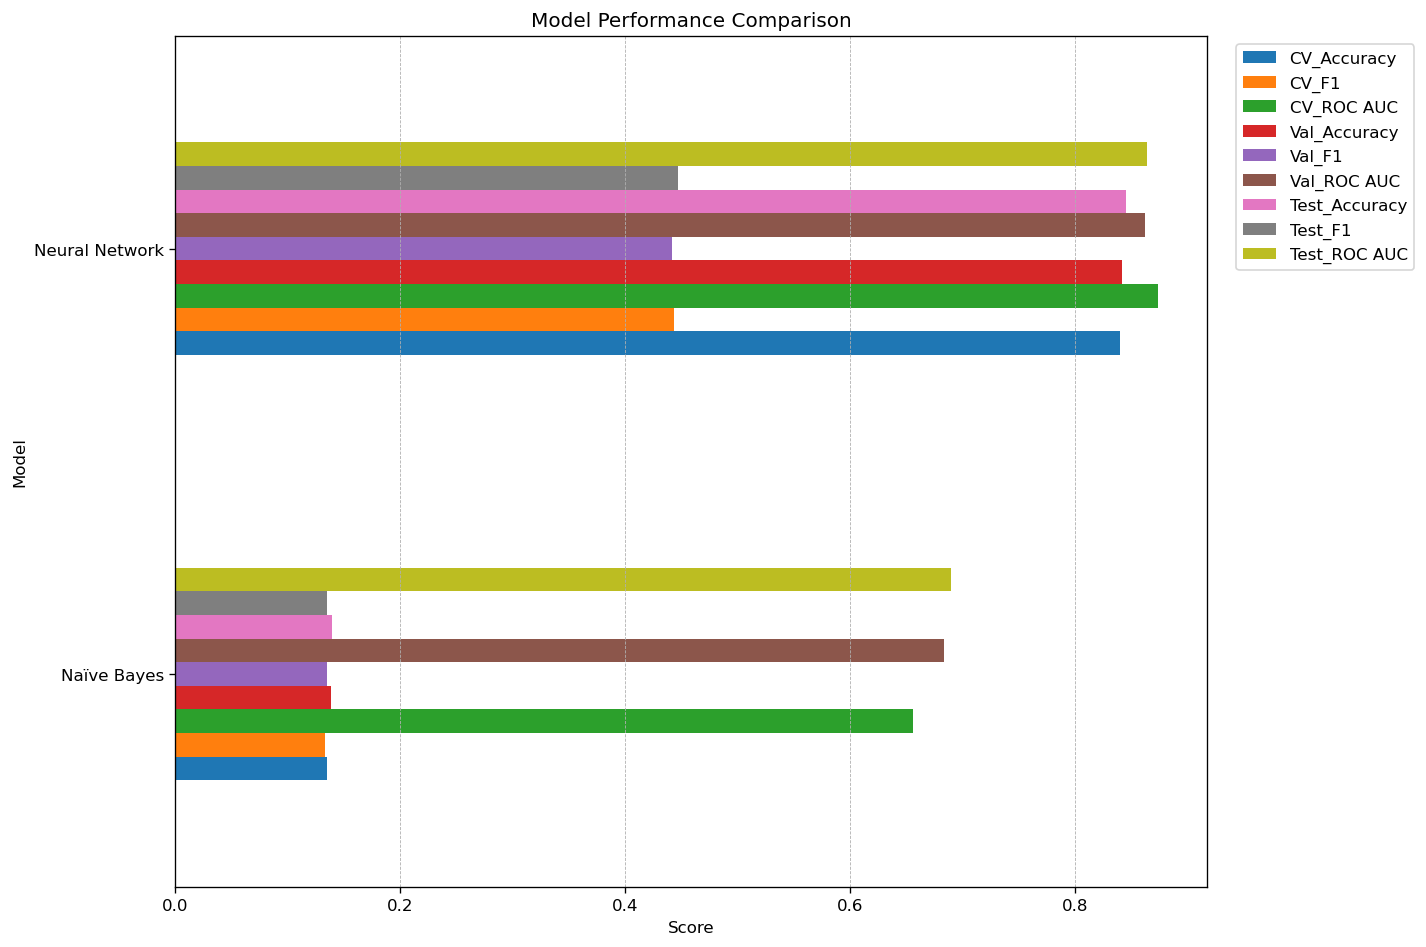


🏆 Best Performing Model (by Test_F1): Neural Network
Test_F1: 0.4473
Test_ROC AUC: 0.8636
Test_Accuracy: 0.8455

🏁 Ranked Test Performance (F1 → ROC AUC → Accuracy)



,Rank,Test_Accuracy,Test_F1,Test_Precision,Test_Recall,Test_ROC AUC
Neural Network,1,0.845471,0.447288,0.295355,0.921118,0.863649
Naïve Bayes,2,0.138945,0.135218,0.072555,0.991687,0.689447


📁 Saved comparison results to: processed_data/outputs\full_model_comparison.csv

=== ✅ RESULTS ANALYSIS COMPLETE ===

=== Test Metrics Summary ===
            Model  Accuracy  Precision (1)  Recall (1)    F1 (1)   ROC AUC
0  Neural Network  0.845471       0.295355    0.921118  0.447288  0.863649
1     Naïve Bayes  0.138945       0.072555    0.991687  0.135218  0.689447

🔎 Computing SHAP for Neural Network...
   Using PermutationExplainer (function_wrapped=True)


PermutationExplainer explainer: 2001it [01:17, 23.76it/s]                          


   ✅ Saved: processed_data/outputs/SHAP\Neural Network_shap_importances.csv
   ✅ Saved: processed_data/outputs/SHAP\Neural Network_shap_bar.png
   ✅ Saved: processed_data/outputs/SHAP\Neural Network_shap_summary.png

🔎 Computing SHAP for Naïve Bayes...
   Using PermutationExplainer (function_wrapped=True)


PermutationExplainer explainer: 2001it [01:17, 22.53it/s]                          


   ✅ Saved: processed_data/outputs/SHAP\Naïve Bayes_shap_importances.csv
   ✅ Saved: processed_data/outputs/SHAP\Naïve Bayes_shap_bar.png
   ✅ Saved: processed_data/outputs/SHAP\Naïve Bayes_shap_summary.png

🔝 Top 10 features for Neural Network:
  1. bwd_bulk_rate  (mean|SHAP|=0.362469)
  2. idle.min  (mean|SHAP|=0.085712)
  3. idle.std  (mean|SHAP|=0.070357)
  4. bwd_bulk_bytes  (mean|SHAP|=0.066720)
  5. active.std  (mean|SHAP|=0.049291)
  6. fwd_iat.max  (mean|SHAP|=0.040111)
  7. bwd_iat.max  (mean|SHAP|=0.035328)
  8. bwd_iat.tot  (mean|SHAP|=0.024742)
  9. bwd_iat.min  (mean|SHAP|=0.018240)
  10. fwd_iat.tot  (mean|SHAP|=0.013413)

🔝 Top 10 features for Naïve Bayes:
  1. idle.min  (mean|SHAP|=0.170401)
  2. idle.std  (mean|SHAP|=0.141753)
  3. bwd_iat.min  (mean|SHAP|=0.058220)
  4. active.std  (mean|SHAP|=0.033832)
  5. fwd_iat.tot  (mean|SHAP|=0.019687)
  6. fwd_bulk_rate  (mean|SHAP|=0.016620)
  7. fwd_bulk_bytes  (mean|SHAP|=0.016537)
  8. bwd_iat.tot  (mean|SHAP|=0.016272)
 

<Figure size 768x576 with 0 Axes>

<Figure size 768x576 with 0 Axes>

In [6]:
# =====================================================
# 5) RESULTS ANALYSIS — works with Step 4 outputs
# =====================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n=== 5) RESULTS ANALYSIS ===")

def _find_metric_key(dct, base):
    """Find a metric key like 'F1', 'F1 (1)', 'F1 (Malicious)'. Returns first match or None."""
    if base in dct:
        return base
    pat = re.compile(rf"^{re.escape(base)}\s*\(.+\)$")
    for k in dct.keys():
        if pat.match(k):
            return k
    return None

def _to_numeric_or_nan(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def _df_to_metrics_dict(test_metrics_csv):
    """
    Load test metrics CSV produced by Step 4 and convert to:
      { 'ModelA': {'Accuracy': 0.99, 'F1 (attack)': 0.98, ...}, ... }
    """
    df = pd.read_csv(test_metrics_csv)
    if 'Model' not in df.columns:
        raise KeyError("Expected a 'Model' column in test metrics CSV.")
    df = df.set_index('Model')
    # Preserve heterogeneous column names (e.g., 'F1 (1)' vs 'F1 (Malicious)')
    out = {}
    for model, row in df.iterrows():
        # Keep strings like "N/A" (we’ll coerce numerics later where needed)
        d = {}
        for c, v in row.items():
            d[c] = v
        out[model] = d
    return out

def analyze_results(cv_results, val_metrics, test_metrics, out_dir="processed_data/outputs"):
    """
    Compare and visualize results across CV → Val → Test.
    Accepts:
      - cv_results: dict like {'Model': {'accuracy': {'mean':..}, 'f1': {'mean':..}, 'roc_auc': {'mean':..}}}
      - val_metrics: dict like {'Model': {'Accuracy':.., 'F1 (...)':.., 'ROC AUC':..}}
      - test_metrics: dict like {'Model': {'Accuracy':.., 'F1 (...)':.., 'ROC AUC':..}}
    """
    os.makedirs(out_dir, exist_ok=True)

    # Defensive defaults
    cv_results  = cv_results  or {}
    val_metrics = {k: v for k, v in (val_metrics  or {}).items() if isinstance(v, dict)}
    test_metrics= {k: v for k, v in (test_metrics or {}).items() if isinstance(v, dict)}

    # ---------- Build Test DF ----------
    test_rows = {}
    for model, md in test_metrics.items():
        row = {}
        if 'Accuracy' in md:
            row['Test_Accuracy'] = _to_numeric_or_nan(md['Accuracy'])
        f1k = _find_metric_key(md, 'F1')
        prk = _find_metric_key(md, 'Precision')
        rck = _find_metric_key(md, 'Recall')
        if f1k is not None: row['Test_F1'] = _to_numeric_or_nan(md[f1k])
        if prk is not None: row['Test_Precision'] = _to_numeric_or_nan(md[prk])
        if rck is not None: row['Test_Recall'] = _to_numeric_or_nan(md[rck])
        if 'ROC AUC' in md: row['Test_ROC AUC'] = _to_numeric_or_nan(md['ROC AUC'])
        if row: test_rows[model] = row
    test_df = pd.DataFrame.from_dict(test_rows, orient='index')

    # ---------- Build Val DF ----------
    val_rows = {}
    for model, md in val_metrics.items():
        row = {}
        if 'Accuracy' in md:
            row['Val_Accuracy'] = _to_numeric_or_nan(md['Accuracy'])
        f1k = _find_metric_key(md, 'F1')
        prk = _find_metric_key(md, 'Precision')
        rck = _find_metric_key(md, 'Recall')
        if f1k is not None: row['Val_F1'] = _to_numeric_or_nan(md[f1k])
        if prk is not None: row['Val_Precision'] = _to_numeric_or_nan(md[prk])
        if rck is not None: row['Val_Recall'] = _to_numeric_or_nan(md[rck])
        if 'ROC AUC' in md: row['Val_ROC AUC'] = _to_numeric_or_nan(md['ROC AUC'])
        if row: val_rows[model] = row
    val_df = pd.DataFrame.from_dict(val_rows, orient='index')

    # ---------- Build CV DF ----------
    cv_rows = {}
    for model, md in cv_results.items():
        row = {}
        if isinstance(md, dict):
            if 'accuracy' in md and isinstance(md['accuracy'], dict):
                row['CV_Accuracy'] = _to_numeric_or_nan(md['accuracy'].get('mean'))
            if 'f1' in md and isinstance(md['f1'], dict):
                row['CV_F1'] = _to_numeric_or_nan(md['f1'].get('mean'))
            if 'roc_auc' in md and isinstance(md['roc_auc'], dict):
                row['CV_ROC AUC'] = _to_numeric_or_nan(md['roc_auc'].get('mean'))
        if row: cv_rows[model] = row
    cv_df = pd.DataFrame.from_dict(cv_rows, orient='index')

    # ---------- Merge ----------
    common = sorted(set(cv_df.index) & set(val_df.index) & set(test_df.index))
    if common:
        full_results = pd.concat([cv_df.loc[common], val_df.loc[common], test_df.loc[common]], axis=1)
    else:
        all_idx = sorted(set(cv_df.index) | set(val_df.index) | set(test_df.index))
        full_results = pd.concat([cv_df.reindex(all_idx), val_df.reindex(all_idx), test_df.reindex(all_idx)], axis=1)

    # coerce numerics
    for c in full_results.columns:
        full_results[c] = pd.to_numeric(full_results[c], errors='coerce')

    print("\n📊 Performance Comparison Across All Phases:\n")
    try:
        from IPython.display import display
        display(full_results)
    except Exception:
        print(full_results)

    # ---------- Plot ----------
    metrics_to_plot = [c for c in full_results.columns
                       if any(k in c for k in ['F1', 'ROC AUC', 'Accuracy'])
                       and pd.api.types.is_numeric_dtype(full_results[c])]
    if metrics_to_plot:
        sort_col = 'Test_F1' if 'Test_F1' in full_results.columns else metrics_to_plot[0]
        plot_df = full_results.sort_values(sort_col, ascending=True)
        ax = plot_df[metrics_to_plot].plot(kind='barh', figsize=(12, 8))
        plt.title('Model Performance Comparison')
        plt.xlabel('Score'); plt.ylabel('Model')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True, axis='x', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No numeric metrics found to plot.")

            # ---------- Best model ----------
    pick = [c for c in ['Test_F1', 'Test_ROC AUC', 'Test_Accuracy'] if c in full_results.columns]
    if pick:
        best_col = pick[0]
        best_model = full_results[best_col].idxmax()
        print(f"\n🏆 Best Performing Model (by {best_col}): {best_model}")
        for c in pick:
            if c in full_results.columns and pd.notna(full_results.loc[best_model, c]):
                print(f"{c}: {full_results.loc[best_model, c]:.4f}")
    else:
        print("⚠️ Could not determine best model—no test metrics present.")
    

    # ---------- Save tables ----------
    os.makedirs(out_dir, exist_ok=True)
    test_cols = [c for c in full_results.columns if c.startswith('Test_')]
    if test_cols:
        test_only = full_results.loc[:, test_cols].copy()
        priority = [c for c in ['Test_F1', 'Test_ROC AUC', 'Test_Accuracy'] if c in test_only.columns] or test_cols
        test_ranked = test_only.sort_values(by=priority, ascending=[False]*len(priority)).copy()
        test_ranked.insert(0, 'Rank', range(1, len(test_ranked) + 1))
        print("\n🏁 Ranked Test Performance (F1 → ROC AUC → Accuracy)\n")
        try:
            from IPython.display import display
            display(test_ranked)
        except Exception:
            print(test_ranked)
        test_ranked.to_csv(os.path.join(out_dir, "test_performance_ranked.csv"), index=True)

    full_results.to_csv(os.path.join(out_dir, "full_model_comparison.csv"))
    print(f"📁 Saved comparison results to: {os.path.join(out_dir, 'full_model_comparison.csv')}")
    return full_results

# ======== HOW TO CALL (Typical) ========
# 1) Load previously computed cv_results / val_metrics dicts (if you saved them).
#    If not available, pass {}.
try:
    cv_results
except NameError:
    cv_results = {}

try:
    val_metrics
except NameError:
    val_metrics = {}

# 2) Convert the Step 4 CSV into the dict format analyze_results expects.
test_metrics_csv = "processed_data/outputs/test_metrics.csv"
test_metrics = _df_to_metrics_dict(test_metrics_csv)

# 3) Run analysis (outputs CSVs and plots into the same outputs folder)
full_results = analyze_results(cv_results, val_metrics, test_metrics,
                               out_dir="processed_data/outputs")

print("\n=== ✅ RESULTS ANALYSIS COMPLETE ===")

#-------------------------------------------------------------
# 4) Print a quick summary table
pd.set_option("display.max_colwidth", 100)
print("\n=== Test Metrics Summary ===")
print(metrics_df)

run_shap_for_models(optimized_models, X_test,
                    out_dir="processed_data/outputs/SHAP",
                    sample_n=2000,
                    verbose=True)

report_top_shap(optimized_models, out_dir="processed_data/outputs/SHAP", k=10)

# Step 6: BEST PERFORMING MODEL SAVED

In [ ]:
# =======================================
#  SAVING THE BEST PERFORMING MODEL (fixed)
# =======================================
print("\n=== 10. SAVING THE BEST MODEL ===")

import os
import re
import json
import math
import joblib
import numpy as np
from datetime import datetime

# ---------- helpers ----------
def _find_metric_key(metrics_dict, base):
    """
    Find a metric key like 'F1', 'F1 (1)', 'F1 (Malicious)' in a model's metrics dict.
    Returns the first matching key or None.
    """
    if base in metrics_dict:
        return base
    # allow variants like "F1 (1)" / "F1 (Malicious)" / "ROC AUC (macro)"
    pat = re.compile(rf"^{re.escape(base)}\s*(\(.+\))?$", flags=re.IGNORECASE)
    for k in metrics_dict.keys():
        if isinstance(k, str) and pat.match(k.strip()):
            return k
    return None

def _to_float(x):
    try:
        v = float(x)
        return None if math.isnan(v) else v
    except Exception:
        return None

def _best_model_by_metrics(test_metrics):
    """
    Choose best model by:
      1) F1 (any variant)  2) ROC AUC  3) Accuracy
    Returns (best_model_name, criterion_used, best_score).
    """
    rows = []
    for model_name, md in test_metrics.items():
        if not isinstance(md, dict):
            md = dict(md)

        f1k = _find_metric_key(md, "F1")
        rok = _find_metric_key(md, "ROC AUC")
        ack = _find_metric_key(md, "Accuracy")

        f1  = _to_float(md.get(f1k)) if f1k else None
        auc = _to_float(md.get(rok)) if rok else None
        acc = _to_float(md.get(ack)) if ack else None

        rows.append((model_name, f1, auc, acc))

    # 1) Pick by F1
    candidates = []
    for (m, f1, _, _) in rows:
        if f1 is not None:
            candidates.append((m, f1))
    if candidates:
        best = max(candidates, key=lambda x: x[1])
        return best[0], "F1", best[1]

    # 2) Then by ROC AUC
    candidates = []
    for (m, _, auc, _) in rows:
        if auc is not None:
            candidates.append((m, auc))
    if candidates:
        best = max(candidates, key=lambda x: x[1])
        return best[0], "ROC AUC", best[1]

    # 3) Then by Accuracy
    candidates = []
    for (m, _, _, acc) in rows:
        if acc is not None:
            candidates.append((m, acc))
    if candidates:
        best = max(candidates, key=lambda x: x[1])
        return best[0], "Accuracy", best[1]

    raise ValueError("No numeric metrics found in test_metrics to select a best model.")

def _safe_filename(name):
    # Lowercase and replace any unsafe char (including spaces, slashes, colons) with '_'
    s = name.lower()
    return re.sub(r"[^a-z0-9._-]+", "_", s)

def _json_default(o):
    # Make json.dump robust to NumPy/Pandas objects
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        v = float(o)
        return None if math.isnan(v) else v
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, (np.ndarray,)):
        return o.tolist()
    # Fallback to string for other non-serializables (e.g., types)
    return str(o)

# ---------- main saver ----------
def save_best_model(optimized_models, test_metrics, bayes_results=None, out_dir="saved_models"):
    """
    Save the best performing model based on test metrics.
    - optimized_models: dict[str, fitted_pipeline]
    - test_metrics: dict like {'ModelName': {'Accuracy':..., 'F1 (...)':..., 'ROC AUC':...}, ...}
    - bayes_results: optional dict to capture pos_label used during tuning
    """
    os.makedirs(out_dir, exist_ok=True)

    best_model_name, criterion, score = _best_model_by_metrics(test_metrics)
    if best_model_name not in optimized_models:
        raise KeyError(f"Best model '{best_model_name}' not found in optimized_models.")

    best_model = optimized_models[best_model_name]

    # Filename-safe model name
    safe_name = _safe_filename(best_model_name)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_path = os.path.join(out_dir, f"best_model_{safe_name}_{timestamp}.pkl")

    joblib.dump(best_model, model_path)
    print(f"\n✅ Saved best model ({best_model_name}, by {criterion}={score:.4f}) to {model_path}")

    # Build metadata
    pos_label = None
    if isinstance(bayes_results, dict) and len(bayes_results) > 0:
        try:
            # take the first model's pos_label if present
            first = next(iter(bayes_results.values()))
            if isinstance(first, dict) and "pos_label" in first:
                pos_label = first["pos_label"]
        except Exception:
            pos_label = None

    metadata = {
        "model_name": best_model_name,
        "selected_by": criterion,
        "selected_score": score,
        "save_timestamp": timestamp,
        "model_path": model_path,
        "model_type": str(type(best_model)),
        "pos_label": pos_label,
        "performance_metrics": test_metrics.get(best_model_name, {}),
    }

    metadata_path = os.path.join(out_dir, f"model_metadata_{timestamp}.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2, default=_json_default)

    print(f"🗂️  Saved model metadata to {metadata_path}")
    return model_path, metadata_path

# ---- Call it (pass bayes_results if available) ----
model_path, metadata_path = save_best_model(optimized_models, test_metrics, bayes_results)